# Principal Component Analysis

## Variance explained by PCs
The first PC captures ~69% of the variance in the data.  
The second PC captures ~19% of the variance.  
The first two PCs capture > 88% of the variance in the data. 

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

penguins_all = pd.read_csv('penguins_af.csv')

In [2]:
penguins_all.columns

Index(['Unnamed: 0', 'species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex', 'year'],
      dtype='object')

In [3]:
penguins_all

,Unnamed: 0,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,0,Adelie,Torgersen,39.1,18.7,181,3750,male,2007
1,1,Adelie,Torgersen,39.5,17.4,186,3800,female,2007
2,2,Adelie,Torgersen,40.3,18.0,195,3250,female,2007
3,4,Adelie,Torgersen,36.7,19.3,193,3450,female,2007
4,5,Adelie,Torgersen,39.3,20.6,190,3650,male,2007
...,...,...,...,...,...,...,...,...,...
328,339,Chinstrap,Dream,55.8,19.8,207,4000,male,2009
329,340,Chinstrap,Dream,43.5,18.1,202,3400,female,2009
330,341,Chinstrap,Dream,49.6,18.2,193,3775,male,2009
331,342,Chinstrap,Dream,50.8,19.0,210,4100,male,2009


In [4]:
species_names=['Adelie','Chinstrap','Gentoo']

X = penguins_all[['bill_length_mm', 'bill_depth_mm','flipper_length_mm', 'body_mass_g']]
y = penguins_all['species']

# Scale input features to N(0,1)
X_scal = StandardScaler().fit_transform(X)

pca = PCA(n_components=4)
X_r = pca.fit(X_scal).transform(X_scal)

# Proportion of variance explained for each components
pca.explained_variance_ratio_

/Users/bbozic/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:757: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
/Users/bbozic/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:595: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/Users/bbozic/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:604: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
/Users/bbozic/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:757: FutureWarning: is_sparse is deprecated and will be removed in a future version. Ch

array([0.68633893, 0.19452929, 0.09216063, 0.02697115])

(0.0, 0.8)

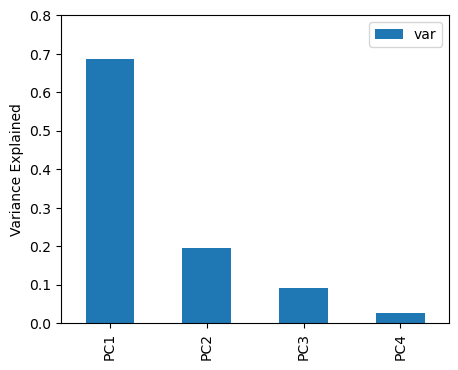

In [5]:
df = pd.DataFrame(pca.explained_variance_ratio_, 
                  index=['PC1','PC2','PC3','PC4'],columns =['var'])

pl = df.plot.bar(figsize=(5,4))
pl.set_ylabel("Variance Explained")
pl.set_ylim([0,0.8])

## Plotting transformed data
Plot the Penguins data using the first two PCs.  
i.e. we are showing the Penguins data transformed into a 2D space where >88% of the variance in the data is preserved. 

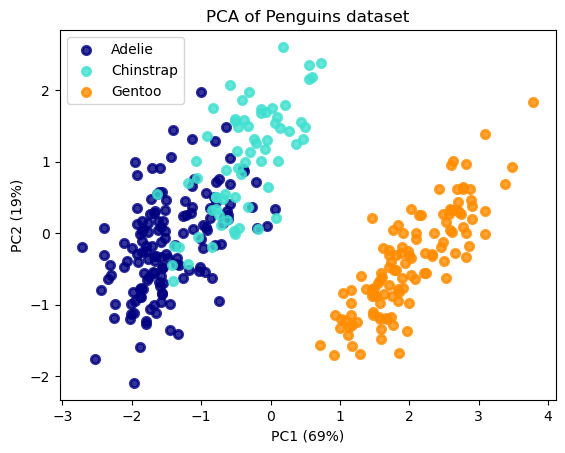

In [6]:
plt.figure()
colors = ['navy', 'turquoise', 'darkorange']
lw = 2

for color, species in zip(colors, species_names):
    plt.scatter(X_r[y == species, 0], X_r[y == species, 1], color=color, alpha=.8, lw=lw,
                label=species)
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.xlabel('PC1 (69%)')
plt.ylabel('PC2 (19%)')
plt.title('PCA of Penguins dataset')

plt.show()

## Top Trumps
`HarryPotterTT.csv` contains data on Top Trumps cards.  
This is an insightful example of clustering because some of the clusters are meaningful and some are not.   

In [7]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
TT_df = pd.read_csv('HarryPotterTT.csv')
TT_df_dash = TT_df.copy()
TT_df.head()

,Name,Magic,Cunning,Courage,Wisdom,Temper
0,'Harry Potter',62,21,42,26,7
1,'Hermione Granger',60,16,40,73,2
2,'Ron Weasley',45,14,40,22,4
3,'Prof. Dumbledore',105,24,39,82,0
4,'Prof. Snape',85,24,19,71,7


In [8]:
y = TT_df.pop('Name').values
X = TT_df.values
X_scal = StandardScaler().fit_transform(X)
X.shape

(22, 5)

In [9]:
pcaHP = PCA(n_components=4)
X_r = pcaHP.fit(X_scal).transform(X_scal)
pcaHP.explained_variance_ratio_

array([0.48877025, 0.31551511, 0.10842469, 0.0501518 ])

In [10]:
pcaHP.components_

array([[ 0.57407296,  0.40754714,  0.3846298 ,  0.57788956, -0.14983036],
       [ 0.10834723,  0.52231617, -0.44046049,  0.0043925 ,  0.72209553],
       [-0.27762934,  0.33155304,  0.76359223, -0.39624817,  0.27001634],
       [ 0.63573329, -0.55900795,  0.19114024, -0.25378831,  0.42709507]])

(0.0, 0.8)

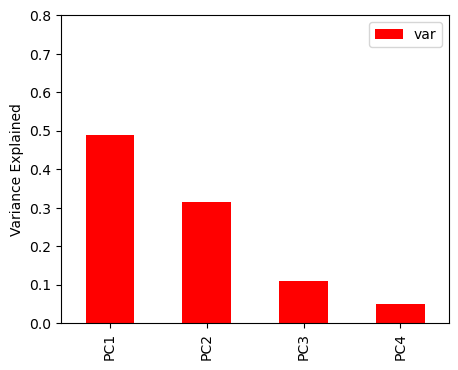

In [11]:
df = pd.DataFrame(pcaHP.explained_variance_ratio_, 
                  index=['PC1','PC2','PC3','PC4'],columns =['var'])

pl = df.plot.bar(color='red',figsize=(5,4))
pl.set_ylabel("Variance Explained")
pl.set_ylim([0,0.8])

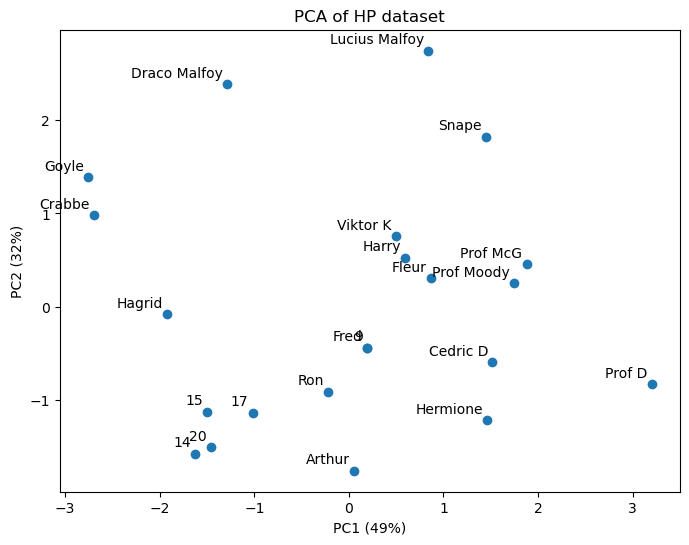

In [12]:
plt.figure(figsize=(8,6))
lw = 2
labels = list(range(len (y)))
labels[0]='Harry'
labels[1]='Hermione'
labels[2]='Ron'
labels[3]='Prof D'
labels[4]='Snape'
labels[5]='Prof McG'
labels[6]='Prof Moody'
labels[7]='Hagrid'
labels[8]='Fred'
labels[10]='Arthur'
labels[11]='Crabbe'
labels[12]='Draco Malfoy'
labels[13]='Goyle'
labels[16]='Fleur'
labels[18]='Cedric D'
labels[19]='Viktor K'
labels[21]='Lucius Malfoy'

plt.scatter(X_r[:, 0], X_r[:, 1])

for label, xi, yi in zip(labels, X_r[:, 0], X_r[:, 1]):
    plt.annotate(
        label,
        xy=(xi, yi), xytext=(-3, 3),
        textcoords='offset points', ha='right', va='bottom')

plt.xlabel('PC1 (49%)')
plt.ylabel('PC2 (32%)')
plt.title('PCA of HP dataset')

plt.show()

In [ ]:
TT_df_dash

# Feature Selection

In [2]:
import pandas as pd
from sklearn.feature_selection import chi2
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import MinMaxScaler

In [8]:
hotel_rev = pd.read_csv('HotelRevHelpfulness.csv')
print(hotel_rev.shape)
hotel_rev.head()

(486, 24)


,aveHelpfulnessRatioUser,stdevHelpfulnessRatioUser,pcReviewsExceedMinHelpfulnessSupport,numReviewsUser,numReviewsHotel,ratingUser,numberSubRatingsUser,subRatingMeanUser,subRatingStdevUser,aveRatingUser,...,completeness_2,completeness_3,numberTermsEntry,percentageAlphaCharsEntry,fractionUpperCaseCharsEntry,fractionYouVsIEntry,numberTermsSummaryQuote,percentageAlphaCharsSummaryQuote,fractionUpperCaseCharsSummaryQuote,reviewHelpfulness
0,1.000000,0.000000,0.666667,3,16,5,4,4.000000,0.000000,4.333333,...,0,1,182,0.788474,0.025703,0.500000,6,0.815789,0.096774,1
1,0.772487,0.377321,0.500000,12,233,5,0,0.000000,0.000000,4.333333,...,0,0,158,0.791888,0.012594,0.500000,1,1.000000,0.083333,1
2,0.715473,0.300437,0.833333,12,302,4,7,3.714286,0.755929,4.166667,...,0,3,59,0.799639,0.024831,0.333333,4,0.828571,0.034483,0
3,0.521250,0.481675,0.222222,36,6,1,4,1.000000,0.000000,3.527778,...,0,0,95,0.782212,0.029155,0.500000,2,0.800000,0.062500,0
4,0.603175,0.246926,1.000000,2,271,3,0,0.000000,0.000000,3.500000,...,0,0,43,0.805128,0.028662,0.000000,1,1.000000,0.142857,0


In [9]:
y = hotel_rev.pop('reviewHelpfulness').values
X = hotel_rev.values
hotel_rev.shape

(486, 23)

## Filter-based Feature Selection
### Feature Scoring - two methods  
1. Chi square statistic
2. Information Gain

In [10]:
chi2_scores, pvals = chi2(X, y)
chi2_scores
# The chi square scores for all the features

array([1.17643855e+00, 1.25630861e+00, 2.97935332e+00, 4.99241616e+02,
       2.09687468e+01, 4.63515335e+00, 1.60567118e+01, 2.34205853e+01,
       1.22221503e-01, 2.01609093e-01, 5.11397162e-01, 4.38593706e-02,
       4.29417810e-02, 1.10399662e+01, 7.01736499e+00, 1.50630136e+01,
       1.35095136e+03, 4.73150717e-03, 3.15477433e-03, 1.96131502e+00,
       2.26290946e-01, 5.28034618e-03, 9.95572153e-03])

In [11]:
# the pvals
pvals

array([2.78082230e-001, 2.62350979e-001, 8.43329611e-002, 1.38988721e-110,
       4.66837118e-006, 3.13233450e-002, 6.14733433e-005, 1.30178029e-006,
       7.26637469e-001, 6.53425155e-001, 4.74534660e-001, 8.34115472e-001,
       8.35834935e-001, 8.91684892e-004, 8.07229379e-003, 1.03980859e-004,
       9.57057321e-296, 9.45160000e-001, 9.55208469e-001, 1.61372749e-001,
       6.34287779e-001, 9.42071913e-001, 9.20520287e-001])

In [12]:
i_scores = mutual_info_classif(X,y)
i_scores
# The i-gain scores for all the features

array([0.03191972, 0.02084097, 0.01085965, 0.07616126, 0.03467594,
       0.        , 0.        , 0.04814829, 0.05009845, 0.03142593,
       0.10166489, 0.0368103 , 0.05379046, 0.00256771, 0.        ,
       0.        , 0.05430948, 0.        , 0.00246319, 0.00222429,
       0.00899376, 0.01256109, 0.0089483 ])

In [13]:
from scipy import stats
stats.spearmanr(chi2_scores, i_scores)
# correlation is low

SpearmanrResult(correlation=0.09731996827283623, pvalue=0.6586676063910695)

In [14]:
mi = dict()

for i,j in zip(hotel_rev.columns,i_scores):
    mi[i]=j

df_mi = pd.DataFrame.from_dict(mi,orient='index',columns=['I-Gain'])
df_mi.sort_values(by=['I-Gain'],ascending=False,inplace=True)
df_mi.head(10)

,I-Gain
stdevRatingUser,0.101665
numReviewsUser,0.076161
numberTermsEntry,0.054309
stdevRatingHotel,0.053790
subRatingStdevUser,0.050098
subRatingMeanUser,0.048148
aveRatingHotel,0.036810
numReviewsHotel,0.034676
aveHelpfulnessRatioUser,0.031920
aveRatingUser,0.031426


In [15]:
chi = dict()
        
chi = {k: (v1, v2) for k, v1, v2 in zip(hotel_rev.columns,chi2_scores, pvals)}        

df_chi = pd.DataFrame.from_dict(chi,orient='index',columns=['Chi2','PVal'])
df_chi.sort_values(by=['Chi2'],ascending=False,inplace=True)
df_chi[df_chi["PVal"] <= 0.05]     # keep those with pvalue of 0.05

,Chi2,PVal
numberTermsEntry,1350.951364,9.570573e-296
numReviewsUser,499.241616,1.389887e-110
subRatingMeanUser,23.420585,1.301780e-06
numReviewsHotel,20.968747,4.668371e-06
numberSubRatingsUser,16.056712,6.147334e-05
completeness_3,15.063014,1.039809e-04
completeness_1,11.039966,8.916849e-04
completeness_2,7.017365,8.072294e-03
ratingUser,4.635153,3.132334e-02


### Image Segmentation Data

In [16]:
seg_data = pd.read_csv('segmentation-all.csv')
print(seg_data.shape)
seg_data.head()

(2310, 20)


,Class,REGION-CENTROID-COL,REGION-CENTROID-ROW,REGION-PIXEL-COUNT,SHORT-LINE-DENSITY-5,SHORT-LINE-DENSITY-2,VEDGE-MEAN,VEDGE-SD,HEDGE-MEAN,HEDGE-SD,INTENSITY-MEAN,RAWRED-MEAN,RAWBLUE-MEAN,RAWGREEN-MEAN,EXRED-MEAN,EXBLUE-MEAN,EXGREEN-MEAN,VALUE-MEAN,SATURATION-MEAN,HUE-MEAN
0,BRICKFACE,140.0,125.0,9,0.0,0.0,0.277778,0.062963,0.666667,0.311111,6.185185,7.333334,7.666666,3.555556,3.444444,4.444445,-7.888889,7.777778,0.545635,-1.121818
1,BRICKFACE,188.0,133.0,9,0.0,0.0,0.333333,0.266667,0.500000,0.077778,6.666666,8.333334,7.777778,3.888889,5.000000,3.333333,-8.333333,8.444445,0.538580,-0.924817
2,BRICKFACE,105.0,139.0,9,0.0,0.0,0.277778,0.107407,0.833333,0.522222,6.111111,7.555555,7.222222,3.555556,4.333334,3.333333,-7.666666,7.555555,0.532628,-0.965946
3,BRICKFACE,34.0,137.0,9,0.0,0.0,0.500000,0.166667,1.111111,0.474074,5.851852,7.777778,6.444445,3.333333,5.777778,1.777778,-7.555555,7.777778,0.573633,-0.744272
4,BRICKFACE,39.0,111.0,9,0.0,0.0,0.722222,0.374074,0.888889,0.429629,6.037037,7.000000,7.666666,3.444444,2.888889,4.888889,-7.777778,7.888889,0.562919,-1.175773


In [17]:
y = seg_data.pop('Class').values
X = seg_data.values
feature_names = seg_data.columns

### Feature Selection

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB
mnb = GaussianNB()

In [19]:
mi = dict()

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2, test_size=1/2)
i_scores = mutual_info_classif(X_train, y_train)

for i,j in zip(feature_names,i_scores):
    mi[i]=j
 
df = pd.DataFrame.from_dict(mi,orient='index',columns=['I-Gain'])
df.sort_values(by=['I-Gain'],ascending=False,inplace=True)
df.head(10)

,I-Gain
RAWRED-MEAN,1.247216
INTENSITY-MEAN,1.155721
HUE-MEAN,1.154586
RAWGREEN-MEAN,1.126935
VALUE-MEAN,1.102576
RAWBLUE-MEAN,1.100394
SATURATION-MEAN,0.955960
REGION-CENTROID-ROW,0.951520
EXGREEN-MEAN,0.941838
EXBLUE-MEAN,0.940361


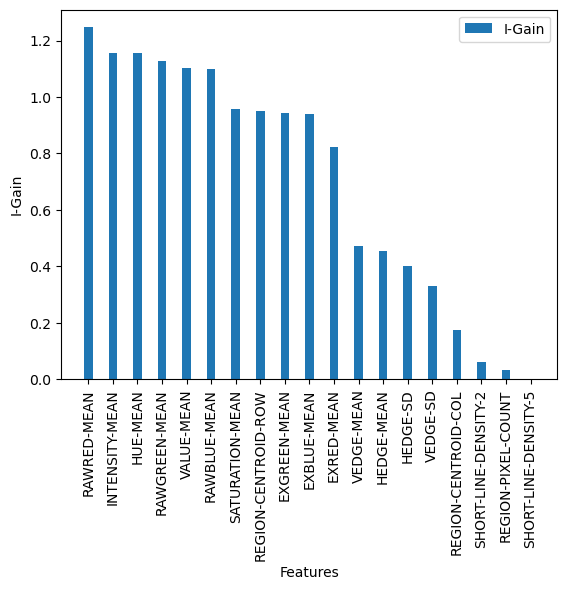

In [20]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline

n = len(df.index)
rr = range(1,n)
fig, ax = plt.subplots()
ax.bar(df.index, df["I-Gain"], label='I-Gain',width=.35)

ax.xaxis.set_major_locator(mticker.FixedLocator(range(0,n)))
ax.set_xticklabels(list(df.index), rotation = 90)

ax.set_xlabel('Features')
ax.set_ylabel('I-Gain')
ax.legend()

plt.show()

## Select *k* Best Features
We rank the features using information gain (well mutual information) and select the _k_ best to build a classifier.  
We iterate through increasing values of *k*.  
`SelectKBest` is a _transform_ that transforms the training data.


In [21]:
acc_scores = []
for kk in range(1, X.shape[1]+1):
    FS_trans = SelectKBest(mutual_info_classif, 
                           k=kk).fit(X_train, y_train)
    X_tR_new = FS_trans.transform(X_train)
    X_tS_new = FS_trans.transform(X_test)
    seg_NB = mnb.fit(X_tR_new, y_train)
    y_dash = seg_NB.predict(X_tS_new)
    acc = accuracy_score(y_test, y_dash)
    acc_scores.append(acc)

df['Accuracy'] = acc_scores
df.head(10)

,I-Gain,Accuracy
RAWRED-MEAN,1.247216,0.553247
INTENSITY-MEAN,1.155721,0.711688
HUE-MEAN,1.154586,0.678788
RAWGREEN-MEAN,1.126935,0.696970
VALUE-MEAN,1.102576,0.677922
RAWBLUE-MEAN,1.100394,0.670996
SATURATION-MEAN,0.955960,0.779221
REGION-CENTROID-ROW,0.951520,0.797403
EXGREEN-MEAN,0.941838,0.783550
EXBLUE-MEAN,0.940361,0.786147


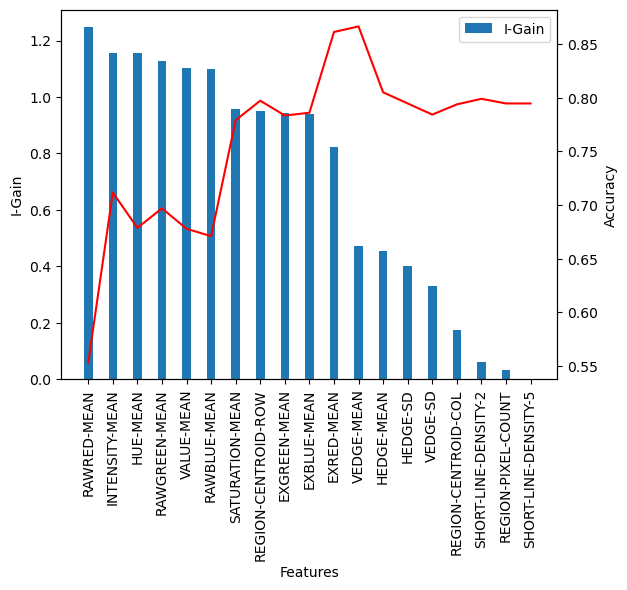

In [22]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline

n = len(df.index)
rr = range(1,n)
fig, ax = plt.subplots()
ax2 = ax.twinx()
ax.bar(df.index, df["I-Gain"], label='I-Gain',width=.35)
ax2.plot(df.index, df["Accuracy"], color='red', label='Accuracy')

ax.xaxis.set_major_locator(mticker.FixedLocator(range(0,n)))

ax.set_xticklabels(list(df.index), rotation = 90)

ax.set_xlabel('Features')
ax.set_ylabel('I-Gain')
ax2.set_ylabel('Accuracy')
ax.legend()

plt.show()

---
## Wrapper
Forward Sequential Search on Image Segmentation data.  

`scikit learn` does support Wrapper feature selection now but doesn't allow us to do the visualisations here
so we use `MLxtend`.  
http://rasbt.github.io/mlxtend/
So you will probably need to install some libraries:  
`pip install mlxtend`  
`pip install joblib`

In [24]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

knn = KNeighborsClassifier(n_neighbors=4)
seg_data = pd.read_csv('segmentation-all.csv')
print(seg_data.shape)
seg_data.head()

(2310, 20)


,Class,REGION-CENTROID-COL,REGION-CENTROID-ROW,REGION-PIXEL-COUNT,SHORT-LINE-DENSITY-5,SHORT-LINE-DENSITY-2,VEDGE-MEAN,VEDGE-SD,HEDGE-MEAN,HEDGE-SD,INTENSITY-MEAN,RAWRED-MEAN,RAWBLUE-MEAN,RAWGREEN-MEAN,EXRED-MEAN,EXBLUE-MEAN,EXGREEN-MEAN,VALUE-MEAN,SATURATION-MEAN,HUE-MEAN
0,BRICKFACE,140.0,125.0,9,0.0,0.0,0.277778,0.062963,0.666667,0.311111,6.185185,7.333334,7.666666,3.555556,3.444444,4.444445,-7.888889,7.777778,0.545635,-1.121818
1,BRICKFACE,188.0,133.0,9,0.0,0.0,0.333333,0.266667,0.500000,0.077778,6.666666,8.333334,7.777778,3.888889,5.000000,3.333333,-8.333333,8.444445,0.538580,-0.924817
2,BRICKFACE,105.0,139.0,9,0.0,0.0,0.277778,0.107407,0.833333,0.522222,6.111111,7.555555,7.222222,3.555556,4.333334,3.333333,-7.666666,7.555555,0.532628,-0.965946
3,BRICKFACE,34.0,137.0,9,0.0,0.0,0.500000,0.166667,1.111111,0.474074,5.851852,7.777778,6.444445,3.333333,5.777778,1.777778,-7.555555,7.777778,0.573633,-0.744272
4,BRICKFACE,39.0,111.0,9,0.0,0.0,0.722222,0.374074,0.888889,0.429629,6.037037,7.000000,7.666666,3.444444,2.888889,4.888889,-7.777778,7.888889,0.562919,-1.175773


In [25]:
y = seg_data.pop('Class').values
X = seg_data.values
feature_names = seg_data.columns


In [26]:
feature_names

Index(['REGION-CENTROID-COL', 'REGION-CENTROID-ROW', 'REGION-PIXEL-COUNT',
       'SHORT-LINE-DENSITY-5', 'SHORT-LINE-DENSITY-2', 'VEDGE-MEAN',
       'VEDGE-SD', 'HEDGE-MEAN', 'HEDGE-SD', 'INTENSITY-MEAN', 'RAWRED-MEAN',
       'RAWBLUE-MEAN', 'RAWGREEN-MEAN', 'EXRED-MEAN', 'EXBLUE-MEAN',
       'EXGREEN-MEAN', 'VALUE-MEAN', 'SATURATION-MEAN', 'HUE-MEAN'],
      dtype='object')

Run forward sequential wrapper search to search across all features using 10-fold xval.  

In [28]:
sfs_forward = SFS(knn, 
                  k_features=10, 
                  forward=True, 
                  floating=False, 
                  verbose=1,
                  scoring='accuracy',
                  cv=5)

sfs_forward = sfs_forward.fit(X, y)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  19 out of  19 | elapsed:    1.0s finished
Features: 1/10[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  18 out of  18 | elapsed:    0.9s finished
Features: 2/10[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  17 out of  17 | elapsed:    0.9s finished
Features: 3/10[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  16 out of  16 | elapsed:    0.8s finished
Features: 4/10[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  15 out of  15 | elapsed:    0.8s finished
Features: 5/10[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  14 out of  14 | elapsed:    0.8s finished
Features: 6/10[Parallel(

#### Plot and see that performance stabilises after 5 or 6 features

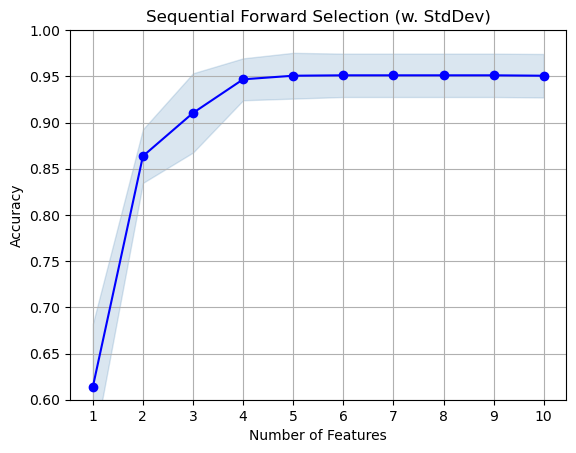

('1', '2', '3', '4', '5', '7', '10', '13', '15', '17')


In [29]:
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
import matplotlib.pyplot as plt

fig1 = plot_sfs(sfs_forward.get_metric_dict(), 
                ylabel='Accuracy',
                kind='std_dev')

plt.ylim([0.6, 1])
plt.title('Sequential Forward Selection (w. StdDev)')
plt.grid()
plt.show()
print(sfs_forward.k_feature_names_)

#### Try backward selection back to 4 features

In [30]:
sfs_backward = SFS(knn, 
                  k_features=4, 
                  forward=False, 
                  floating=False, 
                  verbose=1,
                  scoring='accuracy',
                  cv=10, n_jobs = -1)

sfs_backward = sfs_backward.fit(X, y)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  19 out of  19 | elapsed:    8.0s finished
Features: 18/4[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 out of  18 | elapsed:    0.3s finished
Features: 17/4[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  17 out of  17 | elapsed:    0.3s finished
Features: 16/4[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  16 out of  16 | elapsed:    0.2s finished
Features: 15/4[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  15 out of  15 | elapsed:    0.3s finished
Features: 14/4[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  14 out of  14 | elapsed:    0.2s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  14 out of

#### Plot and see similar performance

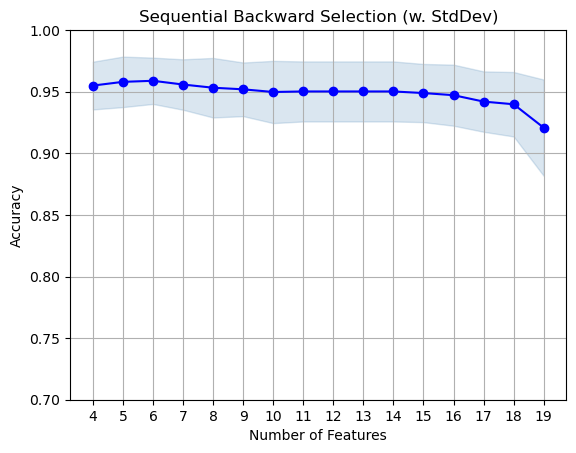

('1', '10', '13', '15')


In [31]:
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
import matplotlib.pyplot as plt

fig1 = plot_sfs(sfs_backward.get_metric_dict(), 
                ylabel='Accuracy',
                kind='std_dev')

plt.ylim([0.7, 1])
plt.title('Sequential Backward Selection (w. StdDev)')
plt.grid()
plt.show()
print(sfs_backward.k_feature_names_)

### Lasso feature selection
Logistic regression with L1 regularisation.   
`SelectFromModel` will select the top features out of max features   
The `C` parameter in `LogisticRegression` is the regularisation parameter, smaller values means stronger regularisation, default is 1.  You can experiment with the value of `C` to see how many features go to zero.     
You can select a specific number of features from `SelectFromModel` using the `max_features` parameter

In [33]:
seg_data = pd.read_csv('segmentation-all.csv')
print(seg_data.shape)
seg_data.head()

(2310, 20)


,Class,REGION-CENTROID-COL,REGION-CENTROID-ROW,REGION-PIXEL-COUNT,SHORT-LINE-DENSITY-5,SHORT-LINE-DENSITY-2,VEDGE-MEAN,VEDGE-SD,HEDGE-MEAN,HEDGE-SD,INTENSITY-MEAN,RAWRED-MEAN,RAWBLUE-MEAN,RAWGREEN-MEAN,EXRED-MEAN,EXBLUE-MEAN,EXGREEN-MEAN,VALUE-MEAN,SATURATION-MEAN,HUE-MEAN
0,BRICKFACE,140.0,125.0,9,0.0,0.0,0.277778,0.062963,0.666667,0.311111,6.185185,7.333334,7.666666,3.555556,3.444444,4.444445,-7.888889,7.777778,0.545635,-1.121818
1,BRICKFACE,188.0,133.0,9,0.0,0.0,0.333333,0.266667,0.500000,0.077778,6.666666,8.333334,7.777778,3.888889,5.000000,3.333333,-8.333333,8.444445,0.538580,-0.924817
2,BRICKFACE,105.0,139.0,9,0.0,0.0,0.277778,0.107407,0.833333,0.522222,6.111111,7.555555,7.222222,3.555556,4.333334,3.333333,-7.666666,7.555555,0.532628,-0.965946
3,BRICKFACE,34.0,137.0,9,0.0,0.0,0.500000,0.166667,1.111111,0.474074,5.851852,7.777778,6.444445,3.333333,5.777778,1.777778,-7.555555,7.777778,0.573633,-0.744272
4,BRICKFACE,39.0,111.0,9,0.0,0.0,0.722222,0.374074,0.888889,0.429629,6.037037,7.000000,7.666666,3.444444,2.888889,4.888889,-7.777778,7.888889,0.562919,-1.175773


In [34]:
y = seg_data.pop('Class').values
X = seg_data.values
feature_names = seg_data.columns

In [35]:
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression

lr_selector = SelectFromModel(LogisticRegression(penalty="l1", 
                     C=.001, solver="liblinear"), max_features=X.shape[1])
lr_selector.fit(X, y)

X=pd.DataFrame(X)
lr_support = lr_selector.get_support()
lr_feature = X.loc[:,lr_support].columns.tolist()
print(str(len(lr_feature)), 'selected features')  
print('Selected features:')
lr_feature

11 selected features
Selected features:


[0, 1, 2, 6, 8, 10, 12, 13, 14, 15, 16]

In [36]:
for i in lr_feature:
    print(feature_names[i])

REGION-CENTROID-COL
REGION-CENTROID-ROW
REGION-PIXEL-COUNT
VEDGE-SD
HEDGE-SD
RAWRED-MEAN
RAWGREEN-MEAN
EXRED-MEAN
EXBLUE-MEAN
EXGREEN-MEAN
VALUE-MEAN


### Random Forest feature selection
Algorithm will select top features out of max features.   
Note that the features selected are different

In [37]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

rf_selector = SelectFromModel(RandomForestClassifier(n_estimators=100),  max_features=X.shape[1])
rf_selector.fit(X, y)

X=pd.DataFrame(X)
rf_support = rf_selector.get_support()
rf_feature = X.loc[:,rf_support].columns.tolist()
print(str(len(rf_feature)), 'selected features')   
print('Selected features:')
rf_feature

/Users/bbozic/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:757: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
/Users/bbozic/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:595: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/Users/bbozic/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:604: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):


8 selected features
Selected features:


[1, 9, 10, 11, 12, 15, 16, 18]